# EDA orientado a Topological Data Analysis (TDA)

**Objetivo**: Explorar la estructura del dataset limpio de logística interplanta para preparar el espacio de features
que alimentará filtraciones (Rips/Čech), diagramas de persistencia y análisis de componentes conexas.

**Fuente**: `/Volumes/jd/sandbox/aws-ae-databricks-sandbox-prod-aws-advance-edl-users-volume/df_clean.xlsx`

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

print("Librerías cargadas.")

Librerías cargadas.


In [0]:
# ─── Carga del dataset limpio ───
RUTA = "/Volumes/jd/sandbox/aws-ae-databricks-sandbox-prod-aws-advance-edl-users-volume/df_clean.xlsx"

!pip install openpyxl
import pandas as pd

RUTA = "/Volumes/jd/sandbox/aws-ae-databricks-sandbox-prod-aws-advance-edl-users-volume/df_clean.xlsx"

# Load the dataset with the correct engine
import pandas as pd

RUTA = "/Volumes/jd/sandbox/aws-ae-databricks-sandbox-prod-aws-advance-edl-users-volume/df_clean.xlsx"
df = pd.read_excel(RUTA, engine="openpyxl")
print(f"Dimensiones: {df.shape[0]:,} filas  {df.shape[1]} columnas")
df.head(5)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(5)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Dimensiones: 64,531 filas  52 columnas
Dimensiones: 64,531 filas × 52 columnas


,C_SOCIEDAD,REMITO,FECHA_ALTA_REMITO,MESREMITO,DIAREMITO,FECHA_SOLICITADA,C_ID_ORDEN_CABECERA,REF_PEDIDO,DOCUMENTO_REFERENCIA,C_POSICION_ORDEN,FECHA_ALTA_ORDEN,FECHA_ALTA_VIAJE,FECHA_SALIDA_ORIGEN,FECHA_LLEGADA_DESTINO,FECHA_PRIMER_PROGRAMACION,TIPO_SERVICIO,D_MEDIO_TRANSPORTE,ID_TIPO_CAMION,NOMBRE_TIPO_CAMION,TIPO_ORDEN,C_ID_VIAJE,N_NRO_PERMISO,TIPO_PERMISO,TIPOTRANSPORTE,PLANTA_ORIGEN,ALMACENPROGRAMADO,C_CLIENTE_DESTINO,DESTINO,ALMACEN_DESTINO,C_ID_TIPO_ESTRATEGIA,C_CLAVE,C_MATERIAL,N_ESPESOR,N_ANCHO,C_UMED,N_CANTIDAD,N_PESO_NETO,N_PESO_BRUTO,D_CARACT_PRODUCTO,D_PRODUCTO,T_USUARIO_ALTA,C_ID_SOLICITUD,SOLICITUD,ID_1330,ALMACEN_CD,ANDEN_CD,GRUISTA_CD,C_CLIENTE_DESTINO_PRESENTE,DOCUMENTO_REFERENCIA_PRESENTE,REF_PEDIDO_PRESENTE,VIAJE_INCOMPLETO,TIEMPO_TRANSITO_H
0,TM01,T00002615415,2026-01-20 17:13:00,1,20,2026-01-21 00:00:00,23496415,DEC3_CHU-260330-17,PROGRAMA,1,2026-01-19 17:31:00,2026-01-20 07:51:00,2026-01-20 17:16:00,2026-01-20 21:05:00,2026-01-20 07:52:00,LO,CAMION,28,Plataforma 3 ejes Neumática,OTD,73930173,15578245,Traslado Externo,Plataforma 3 ejes Neumática,Pesquería,Despacho,NO_APLICA,Churubusco,Runway Decapado,SON,0531075116000010003156696468TR_PSQ_CHU,4A651771PM400,4.572,1136.00,TO,19.490,19.490,19.490,SIN_CARACT,MP546450,oaiusr,11946545,CON SOLICITUD,814959820,Despacho,ZN CARGA A4,TermxIOTSvcUser,0,1,1,0,3.816667
1,TM01,T00002615415,2026-01-20 17:13:00,1,20,2026-01-25 11:20:00,23496859,DEC3_CHU,DESALOJO,1,2026-01-19 19:20:00,2026-01-20 07:51:00,2026-01-20 17:16:00,2026-01-20 21:05:00,2026-01-20 07:52:00,LO,CAMION,28,Plataforma 3 ejes Neumática,OTD,73930173,15578245,Traslado Externo,Plataforma 3 ejes Neumática,Pesquería,Despacho,NO_APLICA,Churubusco,Runway Decapado,SON,0301686115000010002001812071TR_PSQ_CHU,4A652721PM400,6.350,1220.00,TO,19.700,19.700,19.700,SIN_CARACT,MP535351,oaiusr,11947462,CON SOLICITUD,814959820,Despacho,ZN CARGA A4,TermxIOTSvcUser,0,1,1,0,3.816667
2,TM01,T00002613552,2026-01-17 11:17:00,1,17,2026-01-17 05:40:00,23470240,DEC3_CHU,DESALOJO,1,2026-01-15 21:40:00,2026-01-17 07:04:00,2026-01-17 11:19:00,2026-01-17 13:58:00,2026-01-17 09:16:00,LO,CAMION,50,Plataforma 3 Ejes Neumática Corta,OTD,73913122,15567967,Traslado Externo,Plataforma 3 Ejes Neumática Corta,Pesquería,Playa Sur,NO_APLICA,Churubusco,Runway Decapado,SON,0531075226000010003156696606TR_PSQ_CHU,4A651012PM400,7.600,1140.00,TO,19.290,19.290,19.290,SIN_CARACT,MP559762,oaiusr,11915749,CON SOLICITUD,813868447,Playa Sur,Anden 8 Playa Sur,terncalogisticabot,0,1,1,0,2.650000
3,TM01,T00002613552,2026-01-17 11:17:00,1,17,2026-01-25 22:41:00,23479491,DEC3_CHU,DESALOJO,1,2026-01-17 06:41:00,2026-01-17 07:04:00,2026-01-17 11:19:00,2026-01-17 13:58:00,2026-01-17 09:16:00,LO,CAMION,50,Plataforma 3 Ejes Neumática Corta,OTD,73913122,15567967,Traslado Externo,Plataforma 3 Ejes Neumática Corta,Pesquería,Playa Sur,NO_APLICA,Churubusco,Runway Decapado,SON,0301675045000010002001808598TR_PSQ_CHU,4A651393PM400,7.938,1066.04,TO,19.064,19.064,19.064,SIN_CARACT,MP515815,oaiusr,11926733,CON SOLICITUD,813868447,Playa Sur,Anden 8 Playa Sur,terncalogisticabot,0,1,1,0,2.650000
4,TM01,T00002610186,2026-11-01 10:36:00,1,11,2026-05-01 17:57:00,23388215,SL1_CSIN-260101-1,PROGRAMA,1,2026-04-01 09:57:00,2026-09-01 16:06:00,2026-11-01 10:37:00,2026-12-01 10:13:00,2026-09-01 17:31:00,LO,CAMION,68,Plataforma 3 ejes Neumática BIG COIL,OTD,73852562,15545870,Traslado Externo,Plataforma 3 ejes Neumática BIG COIL,Pesquería,Playa Sur,NO_APLICA,CS Industrial Nogalar,MP Nogalar 3,STO,301666113000010,4A642628PS100,1.600,1220.00,TO,19.005,19.005,19.005,MP501067,ROLLO CALIENTE CON SKIN PASS SAE J403 \ 1008 P...,oaiusr,11837612,CON SOLICITUD,811778227,Playa Sur,Anden 4 Playa Sur,terncalogisticabot,0,1,1,0,719.600000


## 1. Perfilado estructural
Tipos de dato, unicidad y porcentaje de nulos por columna.

In [0]:
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(dropna=True),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "ejemplo": [str(df[c].dropna().iloc[0]) if df[c].notna().any() else None for c in df.columns],
})

print(f"Memoria total: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumnas num\u00e9ricas: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Columnas categ\u00f3ricas/texto: {df.select_dtypes(include=['object','category']).shape[1]}")
print(f"Columnas datetime: {df.select_dtypes(include=['datetime']).shape[1]}")
print("\n")
display(resumen)

Memoria total: 129.6 MB

Columnas numéricas: 17
Columnas categóricas/texto: 28
Columnas datetime: 7




dtype,n_unicos,%_nulos,ejemplo
object,2,0.0,TM01
object,29825,0.0,T00002615415
datetime64[ns],28310,0.0,2026-01-20 17:13:00
int64,5,0.0,1
int64,31,0.0,20
datetime64[ns],10798,0.0,2026-01-21 00:00:00
int64,37145,0.0,23496415
object,10647,0.0,DEC3_CHU-260330-17
object,232,0.0,PROGRAMA
int64,31,0.0,1


## 2. Análisis de nulidad
Patrón de co-ocurrencia de nulos: columnas que se ausentan juntas sugieren mecanismo MNAR
(Missing Not At Random), importante para decidir si imputar o excluir antes del TDA.

In [0]:
# Nulos por columna (top 20)
nulos_col = (
    df.isna().sum()
    .to_frame("n_nulos")
    .assign(pct=lambda d: (d.n_nulos / len(df) * 100).round(2))
    .sort_values("n_nulos", ascending=False)
)
print("Top 20 columnas con nulos:")
print(nulos_col.head(20))

# Distribución de nulos por fila
nulos_fila = df.isna().sum(axis=1)
print(f"\nFilas completas (0 nulos): {(nulos_fila == 0).sum()} ({(nulos_fila == 0).mean()*100:.1f}%)")
print(f"Mediana de nulos por fila: {nulos_fila.median():.0f}")

Top 20 columnas con nulos:
                           n_nulos   pct
FECHA_PRIMER_PROGRAMACION     3598  5.58
TIEMPO_TRANSITO_H             1715  2.66
FECHA_LLEGADA_DESTINO         1599  2.48
FECHA_SALIDA_ORIGEN           1146  1.78
MESREMITO                        0  0.00
FECHA_ALTA_REMITO                0  0.00
REMITO                           0  0.00
DIAREMITO                        0  0.00
DOCUMENTO_REFERENCIA             0  0.00
FECHA_SOLICITADA                 0  0.00
C_ID_ORDEN_CABECERA              0  0.00
REF_PEDIDO                       0  0.00
FECHA_ALTA_VIAJE                 0  0.00
FECHA_ALTA_ORDEN                 0  0.00
C_POSICION_ORDEN                 0  0.00
TIPO_SERVICIO                    0  0.00
D_MEDIO_TRANSPORTE               0  0.00
ID_TIPO_CAMION                   0  0.00
NOMBRE_TIPO_CAMION               0  0.00
C_SOCIEDAD                       0  0.00

Filas completas (0 nulos): 60818 (94.2%)
Mediana de nulos por fila: 0


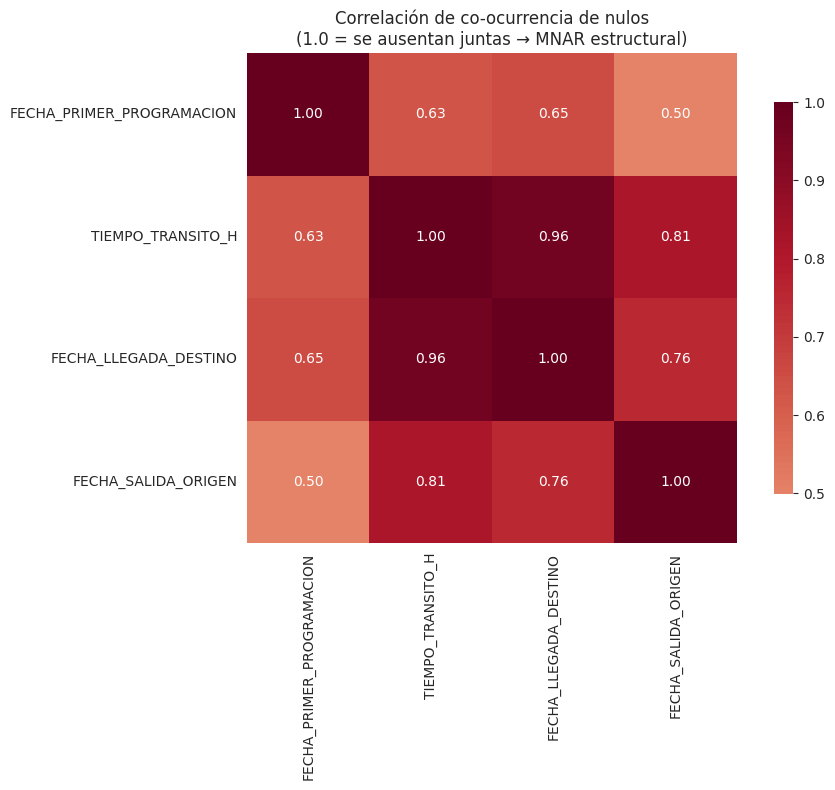

In [0]:
# Correlación entre indicadores de nulidad
cols_nulos = nulos_col[nulos_col.n_nulos > 0].index.tolist()
if len(cols_nulos) >= 2:
    corr_nulos = df[cols_nulos].isna().corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_nulos, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Correlación de co-ocurrencia de nulos\n(1.0 = se ausentan juntas → MNAR estructural)")
    plt.tight_layout()
    plt.show()
else:
    print("Menos de 2 columnas con nulos.")

## 3. Distribuciones numéricas y outliers
Los outliers impactan directamente la nube de puntos del TDA: un punto lejano genera
componentes conexas espúrias en Betti-0 y barras cortas de ruido en el diagrama de persistencia.

In [0]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas ({len(num_cols)}): {num_cols}")

if num_cols:
    desc = df[num_cols].describe().T
    desc["IQR"] = desc["75%"] - desc["25%"]
    desc["outliers_sup"] = [(df[c] > desc.loc[c, "75%"] + 1.5 * desc.loc[c, "IQR"]).sum() for c in num_cols]
    desc["outliers_inf"] = [(df[c] < desc.loc[c, "25%"] - 1.5 * desc.loc[c, "IQR"]).sum() for c in num_cols]
    display(desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "IQR", "outliers_sup", "outliers_inf"]].round(3))

Columnas numéricas (17): ['MESREMITO', 'DIAREMITO', 'C_ID_ORDEN_CABECERA', 'C_POSICION_ORDEN', 'ID_TIPO_CAMION', 'C_ID_VIAJE', 'N_NRO_PERMISO', 'N_ESPESOR', 'N_ANCHO', 'N_CANTIDAD', 'N_PESO_NETO', 'N_PESO_BRUTO', 'C_CLIENTE_DESTINO_PRESENTE', 'DOCUMENTO_REFERENCIA_PRESENTE', 'REF_PEDIDO_PRESENTE', 'VIAJE_INCOMPLETO', 'TIEMPO_TRANSITO_H']


count,mean,std,min,25%,50%,75%,max,IQR,outliers_sup,outliers_inf
64531.0,2.853,1.349,1.0,2.0,3.0,4.0,5.0,2.0,0,0
64531.0,14.69,8.383,1.0,8.0,14.0,21.0,31.0,13.0,0,0
64531.0,2.3825574538E7,282127.879,2.301155E7,2.35806645E7,2.3824471E7,2.40755155E7,2.4317422E7,494851.0,0,0
64531.0,1.228,1.276,1.0,1.0,1.0,1.0,31.0,0.0,4334,0
64531.0,45.345,18.847,7.0,28.0,28.0,68.0,77.0,40.0,0,0
64531.0,7.4207113659E7,228469.678,7.34748E7,7.4009951E7,7.4226033E7,7.4405007E7,7.458508E7,395056.0,0,0
64531.0,1.5743330846E7,130488.896,1.550278E7,1.5628897E7,1.5752098E7,1.585592E7,1.5960704E7,227023.0,0,0
64531.0,2.366,3.264,0.246,0.698,1.35,3.0,250.0,2.302,3912,0
64531.0,1145.342,301.949,218.0,916.0,1189.99,1286.0,1861.0,370.0,406,496
64531.0,14.41,6.704,0.47,9.628,14.28,19.56,36.37,9.932,16,0


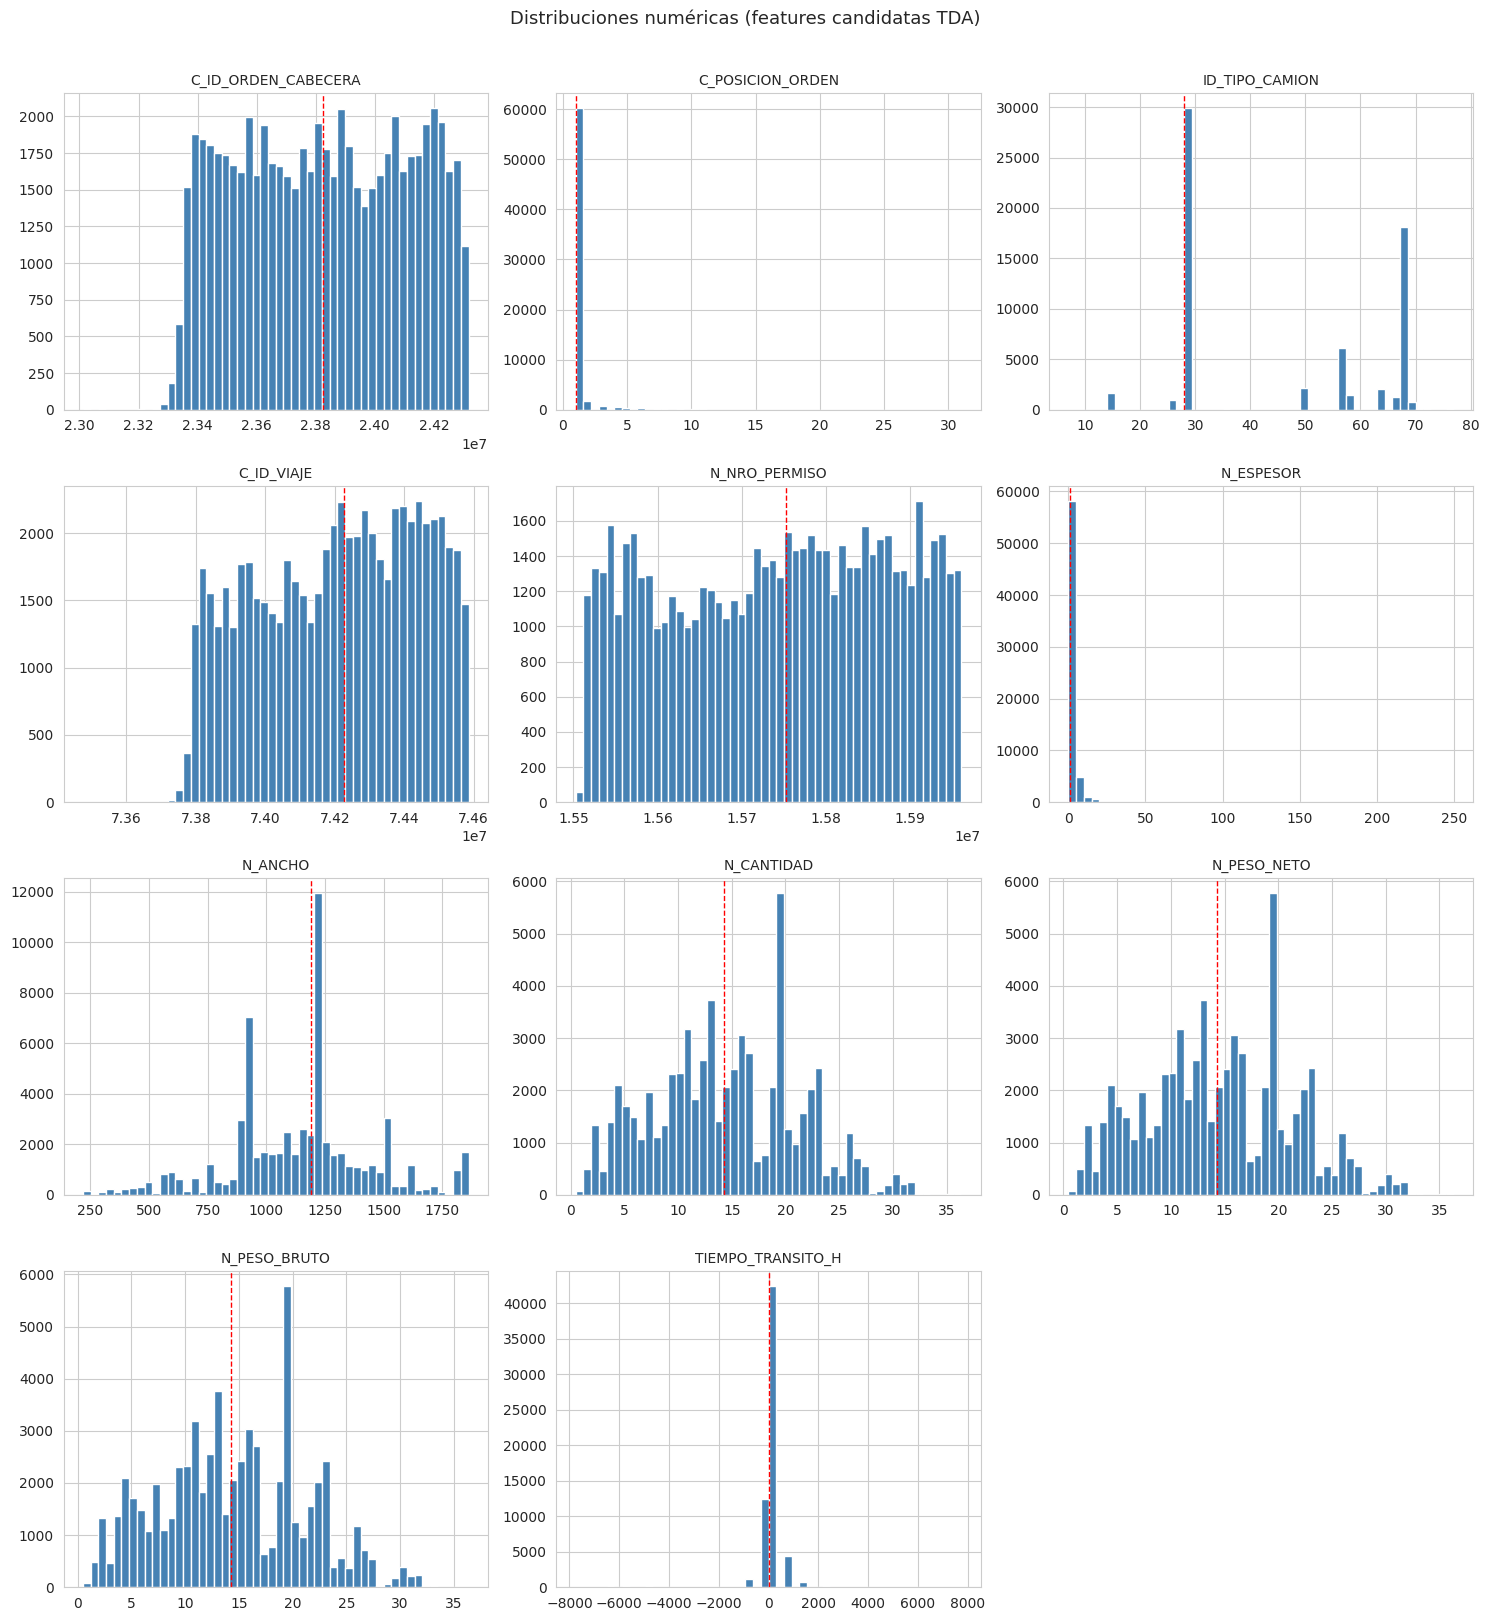

In [0]:
# Histogramas de variables numéricas clave (features candidatas para TDA)
feat_tda = [c for c in num_cols if c not in ["MESREMITO", "DIAREMITO"] 
            and df[c].nunique() > 5]  # excluir IDs y constantes de baja variabilidad

if feat_tda:
    n = len(feat_tda)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()
    for i, c in enumerate(feat_tda):
        df[c].dropna().hist(bins=50, ax=axes[i], color="steelblue", edgecolor="white")
        axes[i].set_title(c, fontsize=10)
        axes[i].axvline(df[c].median(), color="red", ls="--", lw=1, label="mediana")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Distribuciones numéricas (features candidatas TDA)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 4. Correlaciones y redundancias
Columnas altamente correlacionadas (|r| > 0.95) son redundantes en el espacio métrico:
no aportan dimensión topológica nueva y sesgan distancias. Se identifican para excluir.

Pares con |correlación| > 0.95 (candidatos a redundancia):


col_1,col_2,r
N_CANTIDAD,N_PESO_NETO,1.0
N_PESO_NETO,N_PESO_BRUTO,0.9999990277739916
N_CANTIDAD,N_PESO_BRUTO,0.9999990277739916
C_ID_VIAJE,N_NRO_PERMISO,0.9976700551787148
C_ID_ORDEN_CABECERA,C_ID_VIAJE,0.9956746600722867
C_ID_ORDEN_CABECERA,N_NRO_PERMISO,0.9955000720687787
MESREMITO,N_NRO_PERMISO,0.9774008531253462
MESREMITO,C_ID_ORDEN_CABECERA,0.9753995783408871
MESREMITO,C_ID_VIAJE,0.9740319998257927


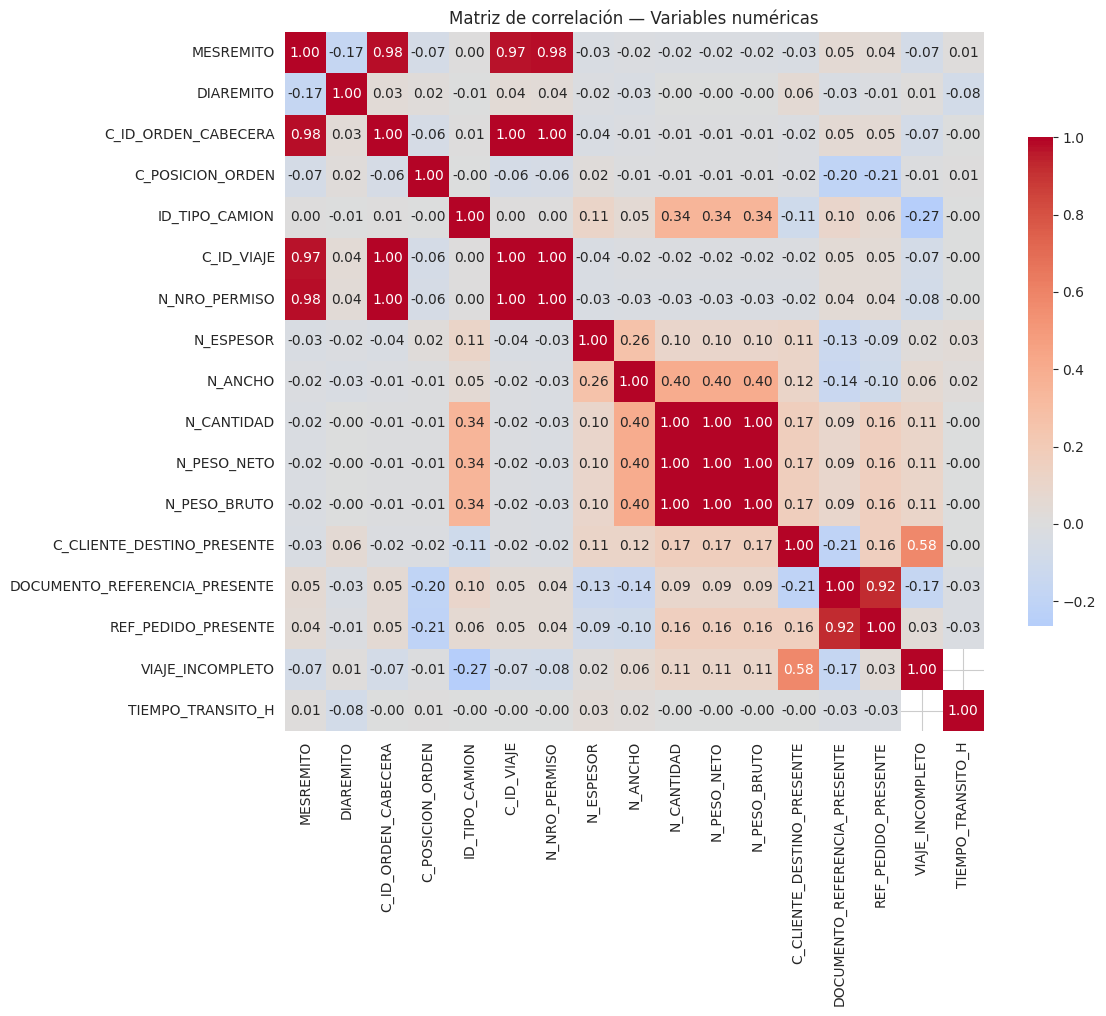

In [0]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    # Pares con |r| > 0.95
    mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
    high_corr = (
        corr.where(mask_upper)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "col_1", "level_1": "col_2", 0: "r"})
        .query("r.abs() > 0.95")
        .sort_values("r", key=abs, ascending=False)
    )
    print("Pares con |correlación| > 0.95 (candidatos a redundancia):")
    display(high_corr)

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, ax=ax, cbar_kws={"shrink": 0.7})
    ax.set_title("Matriz de correlación — Variables numéricas")
    plt.tight_layout()
    plt.show()

## 5. Variables categóricas: cardinalidad y estructura
Las categóricas de baja cardinalidad pueden definir **estratos** para el TDA
(filtraciones por subgrupo). Las de alta cardinalidad se descartan o se codifican.

In [0]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Columnas categóricas ({len(cat_cols)}):")

card_df = pd.DataFrame({
    "columna": cat_cols,
    "n_unicos": [df[c].nunique() for c in cat_cols],
    "%_nulos": [(df[c].isna().mean() * 100) for c in cat_cols],
    "top_valor": [str(df[c].mode().iloc[0]) if not df[c].mode().empty else None for c in cat_cols],
    "freq_top": [df[c].value_counts().iloc[0] if df[c].notna().any() else 0 for c in cat_cols],
}).sort_values("n_unicos", ascending=False).round(2)

display(card_df)

# Estratificadores potenciales (baja cardinalidad)
estratificadores = card_df[card_df.n_unicos <= 20]["columna"].tolist()
print(f"\nEstratos potenciales para TDA (cardinalidad ≤ 20): {estratificadores}")

Columnas categóricas (28):


columna,n_unicos,%_nulos,top_valor,freq_top
C_MATERIAL,64271,0.0,4A605327PD300,3
REMITO,29825,0.0,T00002623904,20
ID_1330,29595,0.0,818862735,20
C_ID_SOLICITUD,21673,0.0,SIN_SOLICITUD,28983
REF_PEDIDO,10647,0.0,SIN_PEDIDO,26777
C_CLAVE,7752,0.0,COMEREDC,6394
D_PRODUCTO,1617,0.0,ROLLO GALVANIZADO CON SKIN PASS Primera,10576
D_CARACT_PRODUCTO,1194,0.0,SIN_CARACT,16611
DOCUMENTO_REFERENCIA,232,0.0,SIN_DOCUMENTO,28653
GRUISTA_CD,140,0.0,terncalogisticabot,35103



Estratos potenciales para TDA (cardinalidad ≤ 20): ['NOMBRE_TIPO_CAMION', 'TIPOTRANSPORTE', 'TIPO_PERMISO', 'TIPO_SERVICIO', 'TIPO_ORDEN', 'C_SOCIEDAD', 'SOLICITUD', 'D_MEDIO_TRANSPORTE', 'PLANTA_ORIGEN', 'C_UMED']


## 6. Selección de features para la nube de puntos (Point Cloud)
Para TDA necesitamos un espacio métrico. Seleccionamos features numéricas relevantes,
normalizamos (StandardScaler) y evaluamos la **dimensión intrínseca** del espacio.

In [0]:
from sklearn.preprocessing import StandardScaler

# Seleccionar features numéricas que NO son IDs ni constantes
id_patterns = ["ID", "NRO_PERMISO", "ORDEN_CABECERA", "SOLICITUD", "1330", "C_ID"]
features_tda = [c for c in num_cols 
                if not any(p in c.upper() for p in id_patterns)
                and df[c].nunique() > 5]

print(f"Features seleccionadas para point cloud ({len(features_tda)}):")
for f in features_tda:
    print(f"  • {f} — {df[f].nunique()} únicos, {df[f].isna().sum()} nulos")

# Preparar matrix: drop nulos en las features seleccionadas
df_pc = df[features_tda].dropna()
print(f"\nFilas disponibles (sin nulos en features TDA): {len(df_pc):,} / {len(df):,}")

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(df_pc)
print(f"Matriz normalizada: {X.shape}")

Features seleccionadas para point cloud (7):
  • DIAREMITO — 31 únicos, 0 nulos
  • C_POSICION_ORDEN — 31 únicos, 0 nulos
  • N_ESPESOR — 2120 únicos, 0 nulos
  • N_ANCHO — 1796 únicos, 0 nulos
  • N_PESO_NETO — 9970 únicos, 0 nulos
  • N_PESO_BRUTO — 15440 únicos, 0 nulos
  • TIEMPO_TRANSITO_H — 5489 únicos, 1715 nulos

Filas disponibles (sin nulos en features TDA): 62,816 / 64,531
Matriz normalizada: (62816, 7)


## 7. Dimensión intrínseca
Estimar la dimensión intrínseca de la nube de puntos ayuda a entender la complejidad topológica
esperada. Se usa PCA (varianza acumulada) y estimación MLE (Maximum Likelihood Estimation).

Dimensiones para 90% varianza: 5
Dimensiones para 95% varianza: 6


/home/spark-afdf5b7d-eb4d-423c-8cac-00/.ipykernel/2710/command-4844177860920090-2211866052:36: RuntimeWarning: divide by zero encountered in divide
  m_hat = (k - 1) / log_ratios.sum(axis=1)


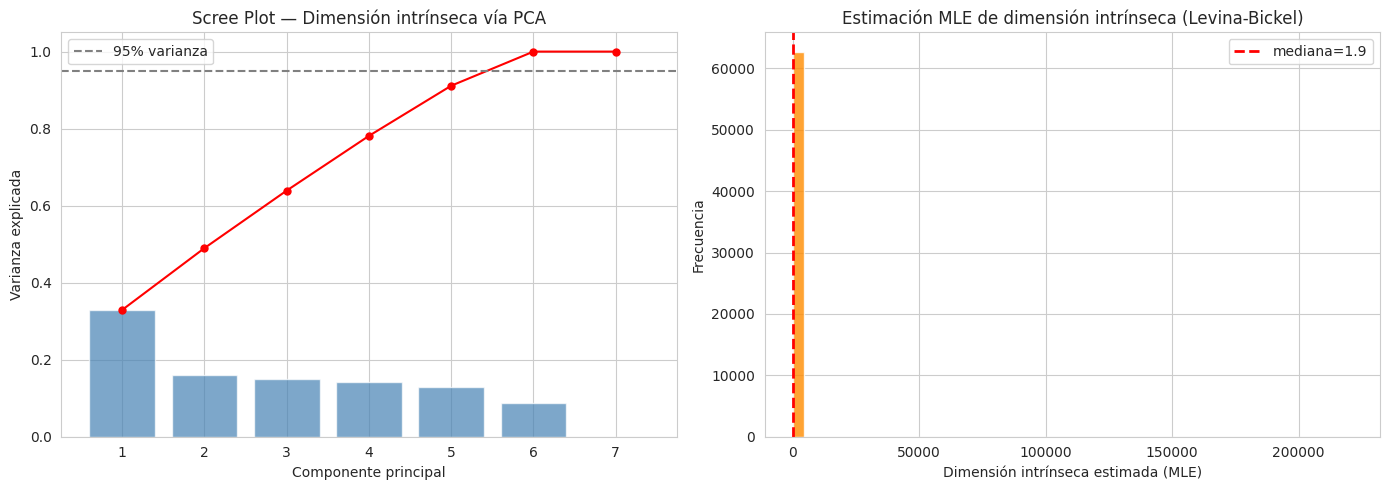


Dimensión intrínseca MLE (mediana): 1.91


In [0]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# PCA: varianza acumulada
pca = PCA().fit(X)
var_acum = np.cumsum(pca.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, color="steelblue", alpha=0.7)
ax1.plot(range(1, len(var_acum) + 1), var_acum, "ro-", markersize=5)
ax1.axhline(0.95, ls="--", color="gray", label="95% varianza")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada")
ax1.set_title("Scree Plot — Dimensión intrínseca vía PCA")
ax1.legend()

# Dimensión para 90% y 95% de varianza
dim_90 = np.argmax(var_acum >= 0.90) + 1
dim_95 = np.argmax(var_acum >= 0.95) + 1
print(f"Dimensiones para 90% varianza: {dim_90}")
print(f"Dimensiones para 95% varianza: {dim_95}")

# Estimación MLE de dimensión intrínseca (Levina-Bickel)
def mle_intrinsic_dim(X, k=10):
    """Estimador MLE de Levina-Bickel para dimensión intrínseca."""
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)
    dists, _ = nn.kneighbors(X)
    dists = dists[:, 1:]  # excluir self-distance
    # Evitar log(0)
    dists = np.maximum(dists, 1e-10)
    T_k = dists[:, -1:]  # distancia al k-ésimo vecino
    log_ratios = np.log(T_k / dists[:, :-1])
    m_hat = (k - 1) / log_ratios.sum(axis=1)
    return m_hat

m_hat = mle_intrinsic_dim(X, k=10)
ax2.hist(m_hat[np.isfinite(m_hat)], bins=50, color="darkorange", edgecolor="white", alpha=0.8)
ax2.axvline(np.median(m_hat), color="red", ls="--", lw=2, label=f"mediana={np.median(m_hat):.1f}")
ax2.set_xlabel("Dimensión intrínseca estimada (MLE)")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Estimación MLE de dimensión intrínseca (Levina-Bickel)")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"\nDimensión intrínseca MLE (mediana): {np.median(m_hat):.2f}")

## 8. Estructura del espacio métrico: distancias y vecindarios-ε
Analizar la distribución de distancias informa sobre:
- **Densidad local**: ¿la nube es homogénea o tiene clusters?
- **Escala de filtración**: ¿en qué rango de ε nacen/mueren los componentes?
- **Separabilidad topológica**: gaps en la distribución de distancias sugieren features topológicas reales.

Calculando matriz de distancias para 3000 puntos...


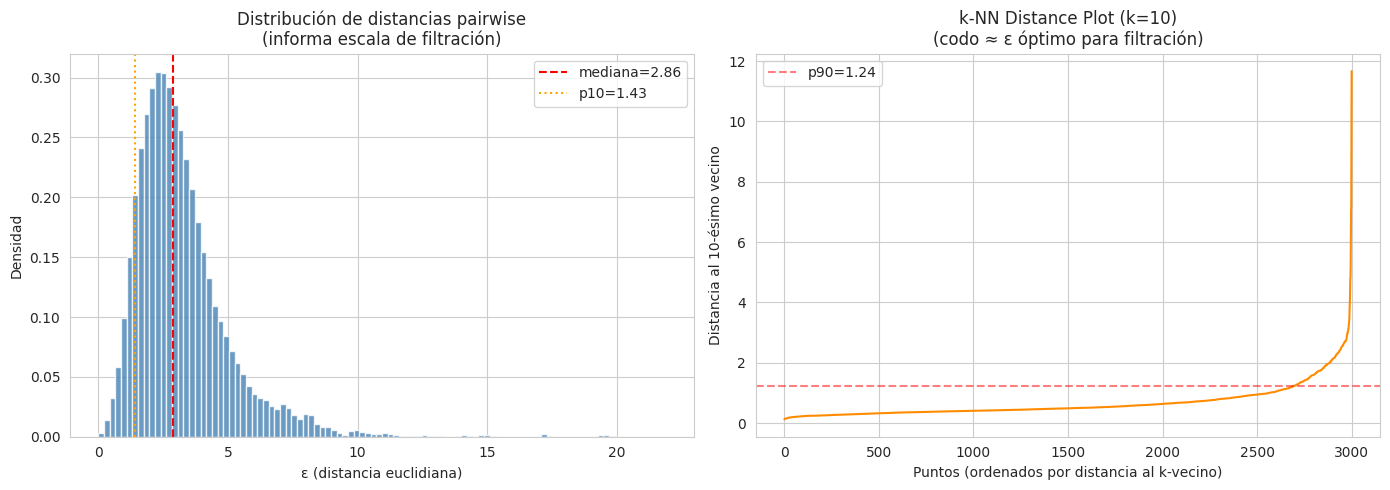


Estadísticas de distancia pairwise:
  Mín: 0.0000
  p10: 1.4302
  Mediana: 2.8636
  p90: 5.4339
  Máx: 21.8928


In [0]:
from sklearn.metrics import pairwise_distances

# Subsamplear para distancias (>5000 puntos es muy pesado para pairwise)
np.random.seed(42)
max_pts = min(3000, len(X))
idx_sample = np.random.choice(len(X), size=max_pts, replace=False)
X_sample = X[idx_sample]

print(f"Calculando matriz de distancias para {max_pts} puntos...")
dist_matrix = pairwise_distances(X_sample, metric="euclidean")

# Distribución de distancias (triángulo superior)
triu_idx = np.triu_indices_from(dist_matrix, k=1)
distancias = dist_matrix[triu_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de distancias
ax1.hist(distancias, bins=100, color="steelblue", edgecolor="white", alpha=0.8, density=True)
ax1.axvline(np.median(distancias), color="red", ls="--", label=f"mediana={np.median(distancias):.2f}")
ax1.axvline(np.percentile(distancias, 10), color="orange", ls=":", label=f"p10={np.percentile(distancias, 10):.2f}")
ax1.set_xlabel("ε (distancia euclidiana)")
ax1.set_ylabel("Densidad")
ax1.set_title("Distribución de distancias pairwise\n(informa escala de filtración)")
ax1.legend()

# k-NN distance plot (para estimar epsilon óptimo tipo DBSCAN/Rips)
k = 10
nn = NearestNeighbors(n_neighbors=k+1).fit(X_sample)
knn_dists, _ = nn.kneighbors(X_sample)
knn_k = np.sort(knn_dists[:, k])  # distancia al k-ésimo vecino, ordenada

ax2.plot(knn_k, color="darkorange", lw=1.5)
ax2.set_xlabel("Puntos (ordenados por distancia al k-vecino)")
ax2.set_ylabel(f"Distancia al {k}-ésimo vecino")
ax2.set_title(f"k-NN Distance Plot (k={k})\n(codo ≈ ε óptimo para filtración)")
ax2.axhline(np.percentile(knn_k, 90), color="red", ls="--", alpha=0.5, label=f"p90={np.percentile(knn_k, 90):.2f}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de distancia pairwise:")
print(f"  Mín: {distancias.min():.4f}")
print(f"  p10: {np.percentile(distancias, 10):.4f}")
print(f"  Mediana: {np.median(distancias):.4f}")
print(f"  p90: {np.percentile(distancias, 90):.4f}")
print(f"  Máx: {distancias.max():.4f}")

## 9. Componentes conexas (Betti-0) vs ε
La curva de Betti-0 muestra cuántas componentes conexas tiene el grafo de vecindad a cada escala ε.
- A ε≈0, cada punto es su propia componente (Betti-0 = n).
- A ε grande, todo está conectado (Betti-0 = 1).
- Los **saltos** en la curva revelan la estructura topológica: clusters reales vs ruido.

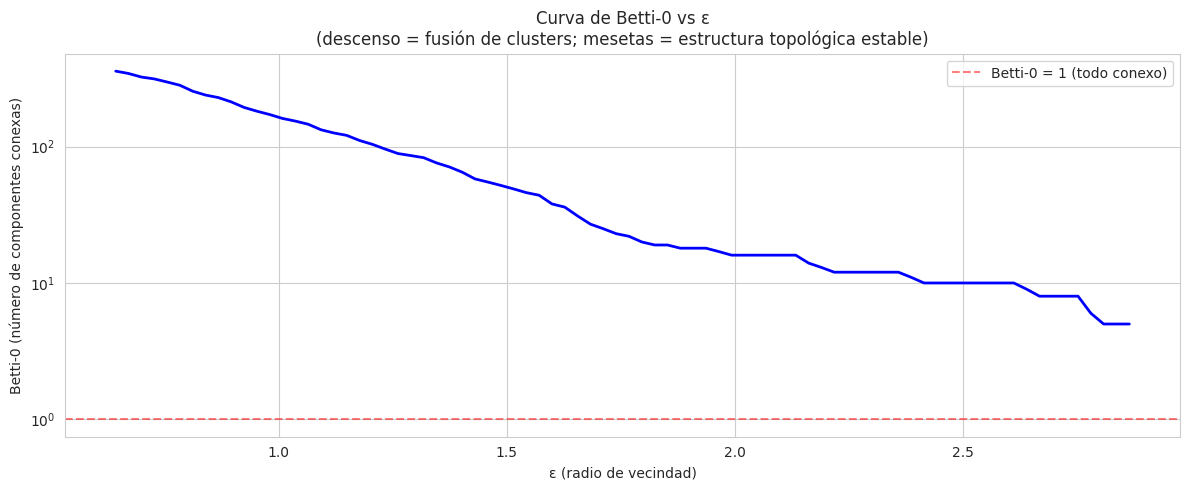

Mesetas significativas (>=3 pasos de ε estables): 4
  Meseta 1: ε ∈ [1.992, 2.133], Betti-0 = 16
  Meseta 2: ε ∈ [2.217, 2.358], Betti-0 = 12
  Meseta 3: ε ∈ [2.414, 2.611], Betti-0 = 10
  Meseta 4: ε ∈ [2.667, 2.751], Betti-0 = 8


In [0]:
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import squareform, pdist

# Rango de epsilon basado en la distribución de distancias
eps_range = np.linspace(np.percentile(distancias, 1), np.percentile(distancias, 50), 80)

# Calcular componentes conexas para cada epsilon
betti_0 = []
for eps in eps_range:
    adj = (dist_matrix <= eps).astype(int)
    np.fill_diagonal(adj, 0)
    n_comp, _ = connected_components(adj, directed=False)
    betti_0.append(n_comp)

betti_0 = np.array(betti_0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eps_range, betti_0, "b-", lw=2)
ax.set_xlabel("ε (radio de vecindad)")
ax.set_ylabel("Betti-0 (número de componentes conexas)")
ax.set_title("Curva de Betti-0 vs ε\n(descenso = fusión de clusters; mesetas = estructura topológica estable)")
ax.set_yscale("log")
ax.axhline(1, color="red", ls="--", alpha=0.5, label="Betti-0 = 1 (todo conexo)")
ax.legend()
plt.tight_layout()
plt.show()

# Detectar mesetas significativas (estabilidad topológica)
diff_betti = np.diff(betti_0)
mesetas = np.where(diff_betti == 0)[0]
if len(mesetas) > 0:
    # Agrupar mesetas consecutivas
    breaks = np.where(np.diff(mesetas) > 1)[0] + 1
    grupos_meseta = np.split(mesetas, breaks)
    mesetas_largas = [g for g in grupos_meseta if len(g) >= 3]
    print(f"Mesetas significativas (>=3 pasos de ε estables): {len(mesetas_largas)}")
    for i, m in enumerate(mesetas_largas[:5]):
        print(f"  Meseta {i+1}: ε ∈ [{eps_range[m[0]]:.3f}, {eps_range[m[-1]+1]:.3f}], Betti-0 = {betti_0[m[0]]}")

## 10. Diagrama de nacimiento-muerte (Birth-Death) — Dimensión 0
El diagrama de persistencia en dimensión 0 muestra cuándo **nace** cada componente conexa
(siempre a ε=0 para puntos individuales) y cuándo **muere** (se fusiona con otra).
- Barras largas = clusters reales (alta persistencia)
- Barras cortas = ruido

Esto es equivalente al **single-linkage dendrogram** y se calcula eficientemente con MST + Union-Find.

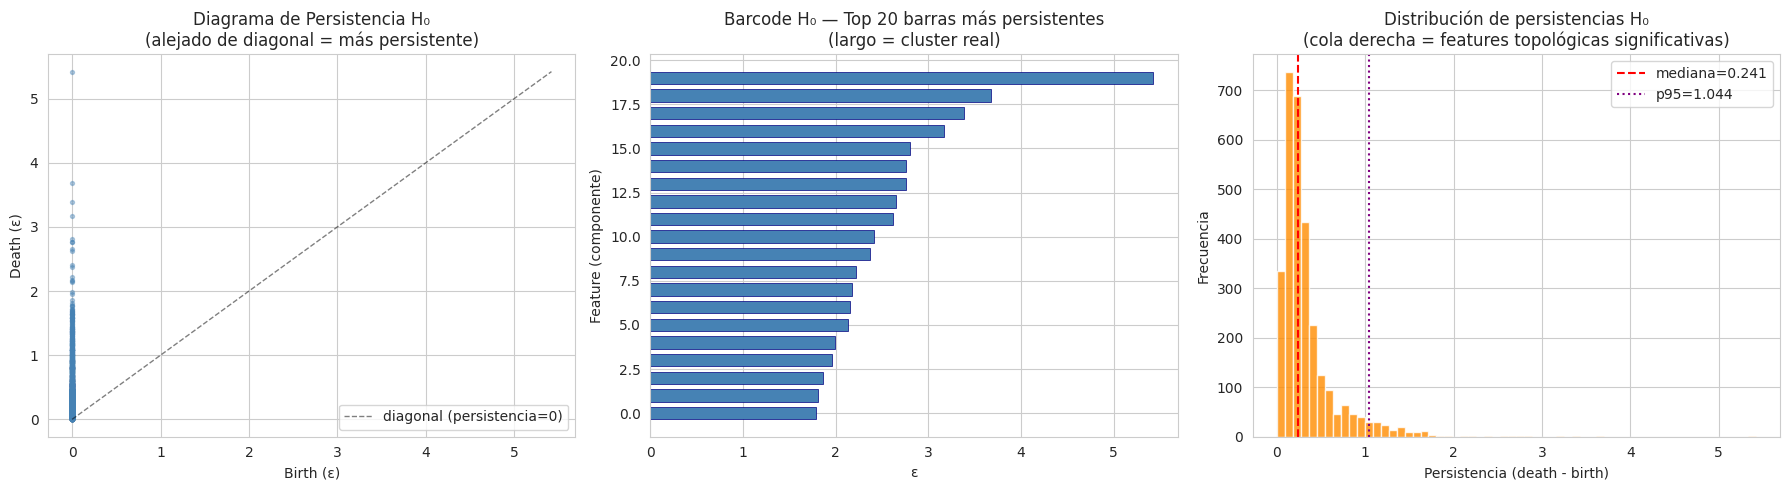


Resumen H₀:
  Total de merges (muertes): 2999
  Persistencia mediana: 0.2409
  Persistencia p95: 1.0443
  Persistencia máxima: 5.4213
  Features con persistencia > p95: 150 (clusters candidatos)


In [0]:
from scipy.cluster.hierarchy import single, fcluster
from scipy.spatial.distance import pdist as scipy_pdist

# Single-linkage = persistence dim 0 vía MST
Z = single(scipy_pdist(X_sample, metric="euclidean"))

# Las alturas de merge en Z son los death times de H0
# Cada punto nace a ε=0; muere cuando se fusiona
death_times = Z[:, 2]  # alturas de merge
birth_times = np.zeros_like(death_times)  # todo nace en 0
persistence_0 = death_times - birth_times  # = death_times

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 10a. Diagrama birth vs death
ax = axes[0]
ax.scatter(birth_times, death_times, s=8, alpha=0.4, c="steelblue")
max_d = death_times.max()
ax.plot([0, max_d], [0, max_d], "k--", lw=1, alpha=0.5, label="diagonal (persistencia=0)")
ax.set_xlabel("Birth (ε)")
ax.set_ylabel("Death (ε)")
ax.set_title("Diagrama de Persistencia H₀\n(alejado de diagonal = más persistente)")
ax.legend()

# 10b. Barcode (top-20 barras más persistentes)
ax = axes[1]
top_idx = np.argsort(persistence_0)[-20:]
for i, idx in enumerate(top_idx):
    ax.barh(i, persistence_0[idx], left=birth_times[idx], height=0.7, 
            color="steelblue", edgecolor="navy", lw=0.5)
ax.set_xlabel("ε")
ax.set_ylabel("Feature (componente)")
ax.set_title("Barcode H₀ — Top 20 barras más persistentes\n(largo = cluster real)")

# 10c. Histograma de persistencias
ax = axes[2]
ax.hist(persistence_0, bins=60, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(np.median(persistence_0), color="red", ls="--", label=f"mediana={np.median(persistence_0):.3f}")
ax.axvline(np.percentile(persistence_0, 95), color="purple", ls=":", 
           label=f"p95={np.percentile(persistence_0, 95):.3f}")
ax.set_xlabel("Persistencia (death - birth)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de persistencias H₀\n(cola derecha = features topológicas significativas)")
ax.legend()

plt.tight_layout()
plt.show()

# Resumen
print(f"\nResumen H₀:")
print(f"  Total de merges (muertes): {len(death_times)}")
print(f"  Persistencia mediana: {np.median(persistence_0):.4f}")
print(f"  Persistencia p95: {np.percentile(persistence_0, 95):.4f}")
print(f"  Persistencia máxima: {persistence_0.max():.4f}")
n_significativas = (persistence_0 > np.percentile(persistence_0, 95)).sum()
print(f"  Features con persistencia > p95: {n_significativas} (clusters candidatos)")

## 11. Homología en dimensión superior (H₁ — loops)
Usamos la filtración Rips con `ripser` para detectar **ciclos** (H₁) en la nube de puntos.
Estos ciclos representan "huecos" 1-dimensionales en la topología del dato.

In [0]:
# Instalar ripser si no está disponible
try:
    from ripser import ripser
    print("ripser disponible.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "ripser", "-q"], check=True)
    from ripser import ripser
    print("ripser instalado y cargado.")

# Subsamplear más agresivamente para Rips (complejidad O(n^3))
max_rips = min(1500, len(X_sample))
idx_rips = np.random.choice(len(X_sample), size=max_rips, replace=False)
X_rips = X_sample[idx_rips]

print(f"Calculando filtración Rips para {max_rips} puntos (H0 y H1)...")
result = ripser(X_rips, maxdim=1, thresh=np.percentile(distancias, 50))

print(f"\nResultados:")
for dim, dgm in enumerate(result["dgms"]):
    finite_bars = dgm[dgm[:, 1] < np.inf]
    print(f"  H{dim}: {len(dgm)} features ({len(finite_bars)} finitas, {(dgm[:, 1] == np.inf).sum()} infinitas)")


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


ripser instalado y cargado.
Calculando filtración Rips para 1500 puntos (H0 y H1)...

Resultados:
  H0: 1497 features (1494 finitas, 3 infinitas)
  H1: 702 features (700 finitas, 2 infinitas)


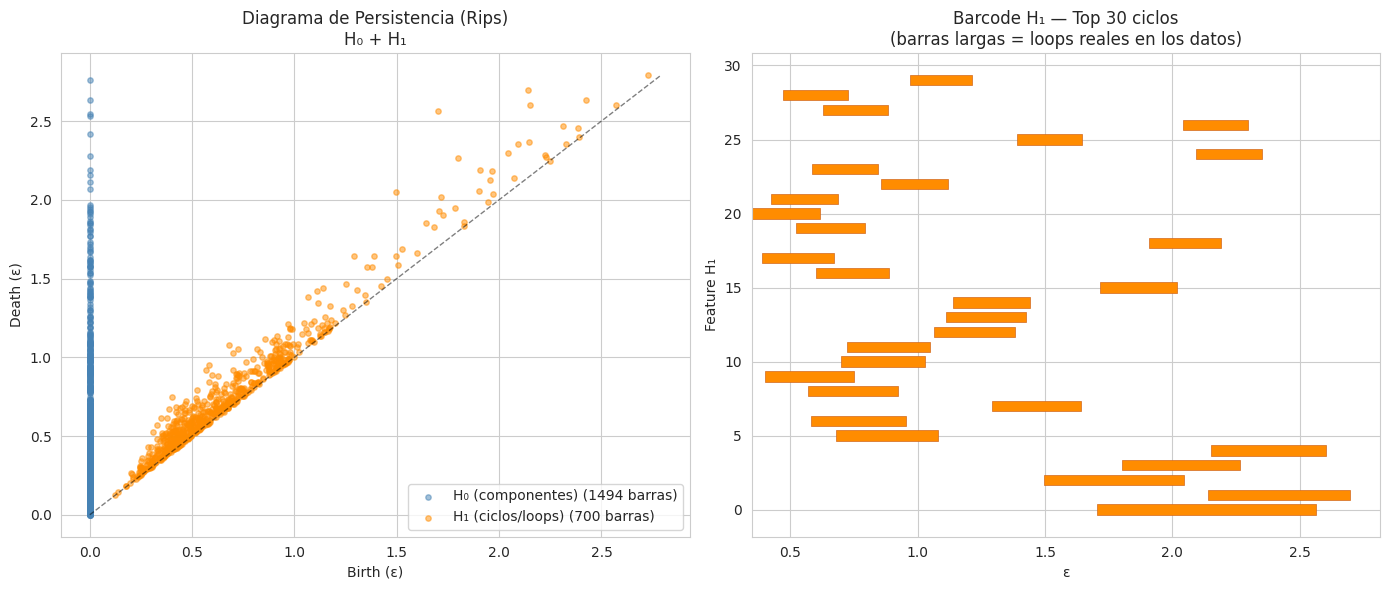


Resumen H₁ (ciclos):
  Total ciclos finitos: 700
  Persistencia mediana: 0.0528
  Persistencia máxima: 0.8610
  Ciclos con alta persistencia (>p90): 70


In [0]:
# Diagrama de persistencia H0 + H1 combinado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["steelblue", "darkorange"]
labels = ["H₀ (componentes)", "H₁ (ciclos/loops)"]

# Diagrama de persistencia
ax = axes[0]
for dim, dgm in enumerate(result["dgms"]):
    finite = dgm[dgm[:, 1] < np.inf]
    if len(finite) > 0:
        ax.scatter(finite[:, 0], finite[:, 1], s=15, alpha=0.5, 
                   c=colors[dim], label=f"{labels[dim]} ({len(finite)} barras)")
max_val = max(dgm[dgm[:, 1] < np.inf][:, 1].max() for dgm in result["dgms"] if len(dgm[dgm[:, 1] < np.inf]) > 0)
ax.plot([0, max_val], [0, max_val], "k--", lw=1, alpha=0.5)
ax.set_xlabel("Birth (ε)")
ax.set_ylabel("Death (ε)")
ax.set_title("Diagrama de Persistencia (Rips)\nH₀ + H₁")
ax.legend()

# Barcode H1
ax = axes[1]
h1 = result["dgms"][1]
h1_finite = h1[h1[:, 1] < np.inf]
if len(h1_finite) > 0:
    # Ordenar por persistencia
    pers = h1_finite[:, 1] - h1_finite[:, 0]
    order = np.argsort(pers)[::-1]
    n_show = min(30, len(h1_finite))
    for i in range(n_show):
        idx = order[i]
        ax.barh(i, pers[idx], left=h1_finite[idx, 0], height=0.7,
                color="darkorange", edgecolor="chocolate", lw=0.5)
    ax.set_xlabel("ε")
    ax.set_ylabel("Feature H₁")
    ax.set_title(f"Barcode H₁ — Top {n_show} ciclos\n(barras largas = loops reales en los datos)")
else:
    ax.text(0.5, 0.5, "No se detectaron ciclos H₁", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Barcode H₁")

plt.tight_layout()
plt.show()

# Análisis de persistencias H1
if len(h1_finite) > 0:
    pers_h1 = h1_finite[:, 1] - h1_finite[:, 0]
    print(f"\nResumen H₁ (ciclos):")
    print(f"  Total ciclos finitos: {len(h1_finite)}")
    print(f"  Persistencia mediana: {np.median(pers_h1):.4f}")
    print(f"  Persistencia máxima: {pers_h1.max():.4f}")
    print(f"  Ciclos con alta persistencia (>p90): {(pers_h1 > np.percentile(pers_h1, 90)).sum()}")

## 12. Landscape de persistencia
El persistence landscape es una representación funcional estable del diagrama de persistencia,
útil para integrar con ML (se puede promediar, usar como feature vector, etc.).

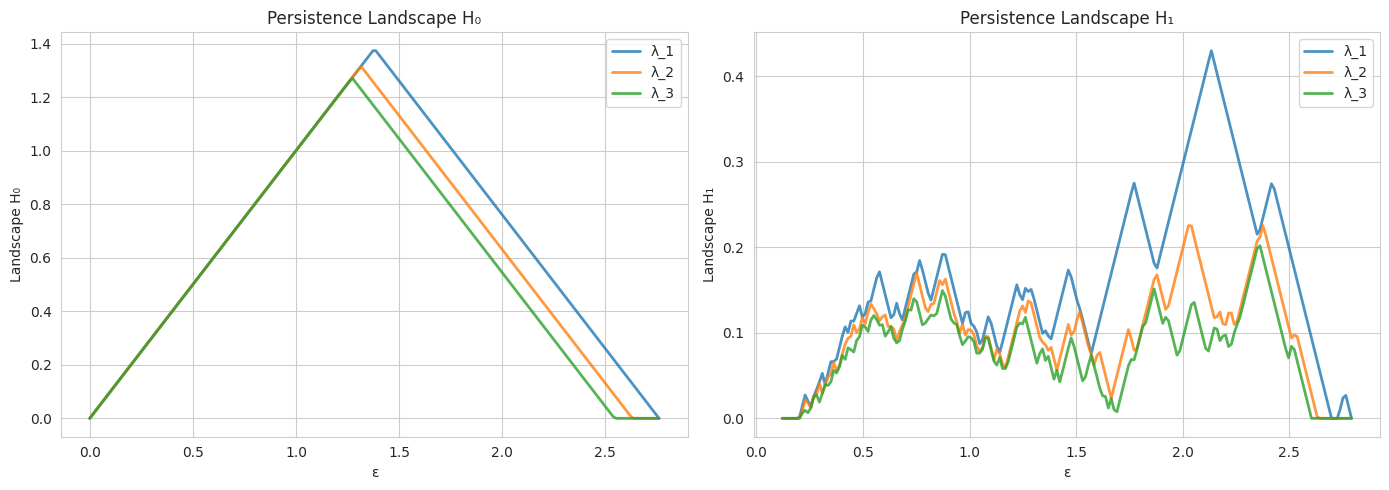

In [0]:
def persistence_landscape(dgm, num_steps=200, k=1):
    """Calcula el k-ésimo persistence landscape."""
    finite = dgm[dgm[:, 1] < np.inf]
    if len(finite) == 0:
        return np.zeros(num_steps), np.zeros(num_steps)
    
    births = finite[:, 0]
    deaths = finite[:, 1]
    t_min = births.min()
    t_max = deaths.max()
    t_vals = np.linspace(t_min, t_max, num_steps)
    
    # Para cada t, calcular las funciones tent
    landscapes = np.zeros((len(finite), num_steps))
    for i in range(len(finite)):
        b, d = births[i], deaths[i]
        mid = (b + d) / 2
        for j, t in enumerate(t_vals):
            if b <= t <= mid:
                landscapes[i, j] = t - b
            elif mid < t <= d:
                landscapes[i, j] = d - t
    
    # k-th landscape = k-th largest at each t
    landscapes_sorted = np.sort(landscapes, axis=0)[::-1]
    if k <= len(landscapes_sorted):
        return t_vals, landscapes_sorted[k-1]
    else:
        return t_vals, np.zeros(num_steps)

# Landscapes para H0 y H1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dim, (ax, title) in enumerate(zip(axes, ["H₀", "H₁"])):
    dgm = result["dgms"][dim]
    for k in [1, 2, 3]:
        t_vals, landscape = persistence_landscape(dgm, num_steps=200, k=k)
        if landscape.max() > 0:
            ax.plot(t_vals, landscape, lw=2, label=f"λ_{k}", alpha=0.8)
    ax.set_xlabel("ε")
    ax.set_ylabel(f"Landscape {title}")
    ax.set_title(f"Persistence Landscape {title}")
    ax.legend()

plt.tight_layout()
plt.show()

## 13. Proyección 2D de la nube de puntos (UMAP)
Visualizamos la nube de puntos en 2D para correlacionar visualmente con la estructura topológica
detectada (clusters = componentes conexas, holes = ciclos H₁).


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


umap instalado y cargado.


/local_disk0/.ephemeral_nfs/envs/pythonEnv-afdf5b7d-eb4d-423c-8cac-006c9d855a31/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


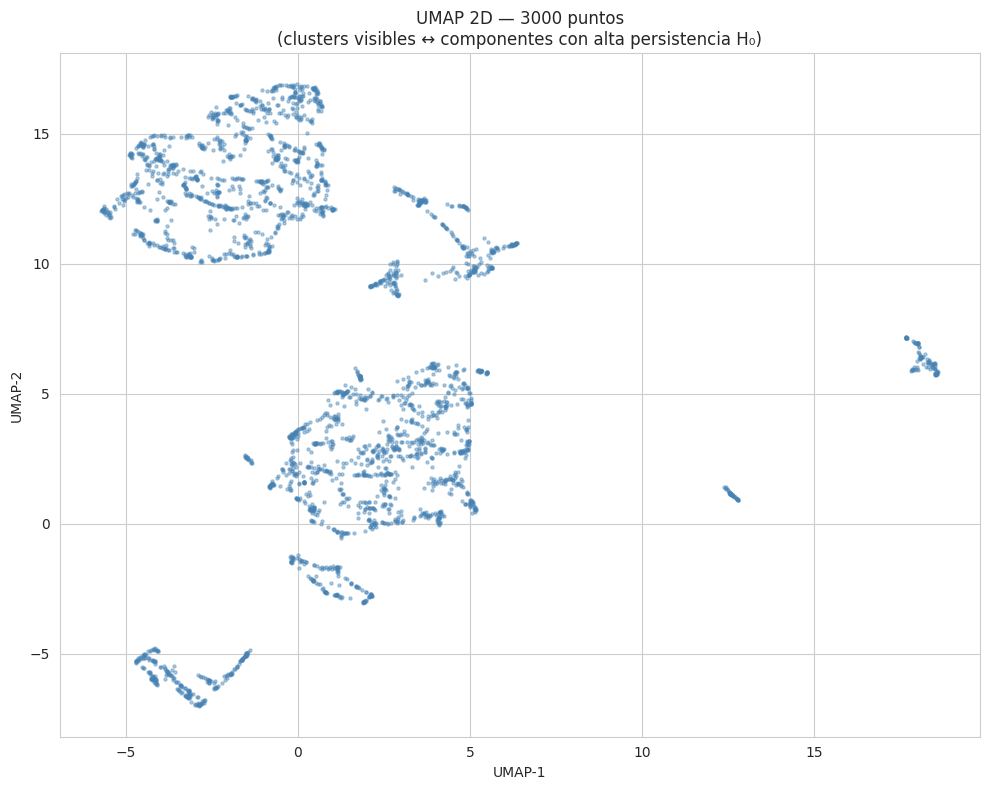

In [0]:
try:
    import umap
    print("umap disponible.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "-q"], check=True)
    import umap
    print("umap instalado y cargado.")

# UMAP sobre la muestra
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.4, c="steelblue")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"UMAP 2D — {max_pts} puntos\n(clusters visibles ↔ componentes con alta persistencia H₀)")
plt.tight_layout()
plt.show()

## 14. Resumen y conclusiones para TDA

| Aspecto | Resultado | Implicación para TDA |
|---------|-----------|---------------------|
| Dimensión intrínseca | PCA + MLE | Define la complejidad esperada de la topología |
| Escala de filtración | k-NN plot + dist. pairwise | Rango de ε para Rips/Čech |
| Componentes (H₀) | Curva Betti-0 + barcode | Número de clusters topológicos estables |
| Ciclos (H₁) | Rips persistence | Huecos/loops en el espacio de datos |
| Ruido vs señal | Persistencia p95 | Umbral para separar features reales de artefactos |

In [0]:
# ─── RESUMEN EJECUTIVO ───
print("="*70)
print("RESUMEN EDA ORIENTADO A TDA")
print("="*70)
print(f"\n1. DATASET")
print(f"   Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"   Features para point cloud: {len(features_tda)}")
print(f"   Filas sin nulos (usables): {len(df_pc):,} ({len(df_pc)/len(df)*100:.1f}%)")

print(f"\n2. DIMENSIÓN INTRÍNSECA")
print(f"   PCA 95% varianza: {dim_95} dimensiones")
print(f"   MLE Levina-Bickel (mediana): {np.median(m_hat):.1f} dimensiones")

print(f"\n3. ESPACIO MÉTRICO")
print(f"   Distancia mediana pairwise: {np.median(distancias):.3f}")
print(f"   Rango sugerido filtración: [{np.percentile(distancias, 5):.3f}, {np.percentile(distancias, 50):.3f}]")

print(f"\n4. TOPOLOGÍA H₀ (Componentes)")
print(f"   Merges totales: {len(death_times)}")
print(f"   Persistencia máxima: {persistence_0.max():.4f}")
print(f"   Clusters significativos (>p95): {n_significativas}")

if len(h1_finite) > 0:
    print(f"\n5. TOPOLOGÍA H₁ (Ciclos)")
    print(f"   Ciclos detectados: {len(h1_finite)}")
    print(f"   Persistencia máxima H₁: {pers_h1.max():.4f}")
    print(f"   Ciclos significativos (>p90): {(pers_h1 > np.percentile(pers_h1, 90)).sum()}")

print(f"\n6. RECOMENDACIONES PARA TDA")
print(f"   • Usar filtración Rips con ε_max ≈ {np.percentile(distancias, 50):.2f}")
print(f"   • Considerar subsampling a ~2000-3000 puntos para eficiencia")
print(f"   • Normalizar SIEMPRE antes de computar distancias")
print(f"   • Investigar features con persistencia > {np.percentile(persistence_0, 95):.3f} (H₀)")
print("="*70)

RESUMEN EDA ORIENTADO A TDA

1. DATASET
   Filas: 64,531 | Columnas: 52
   Features para point cloud: 7
   Filas sin nulos (usables): 62,816 (97.3%)

2. DIMENSIÓN INTRÍNSECA
   PCA 95% varianza: 6 dimensiones
   MLE Levina-Bickel (mediana): 1.9 dimensiones

3. ESPACIO MÉTRICO
   Distancia mediana pairwise: 2.864
   Rango sugerido filtración: [1.133, 2.864]

4. TOPOLOGÍA H₀ (Componentes)
   Merges totales: 2999
   Persistencia máxima: 5.4213
   Clusters significativos (>p95): 150

5. TOPOLOGÍA H₁ (Ciclos)
   Ciclos detectados: 700
   Persistencia máxima H₁: 0.8610
   Ciclos significativos (>p90): 70

6. RECOMENDACIONES PARA TDA
   • Usar filtración Rips con ε_max ≈ 2.86
   • Considerar subsampling a ~2000-3000 puntos para eficiencia
   • Normalizar SIEMPRE antes de computar distancias
   • Investigar features con persistencia > 1.044 (H₀)
